In [2]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd())) 

In [3]:


import pandas as pd
import matplotlib.pyplot as plt

from src.steps.model.run_stage1 import run_stage1
from src.steps.model.run_stage2 import run_stage2
from src.steps.model.run_stage3 import run_stage3

from src.steps.model.diff_game_game_theory import SingleGameSim

from src.config import Config


In [40]:
d0 = pd.read_csv(Path(input_path))

In [41]:
d0.head()

,SEASON_ID,GAME_ID,GAME_DATE,AWAY_TEAM_ID,HOME_TEAM_ID,AWAY_TEAM_ABBREVIATION,HOME_TEAM_ABBREVIATION,AWAY_TEAM_NAME,HOME_TEAM_NAME,AWAY_FGM,...,BOX_OUTS_DIFF,DEF_LOOSE_BALLS_RECOVERED_DIFF,SCREEN_ASSISTS_DIFF,BOX_OUT_PLAYER_REBS_DIFF,OFF_LOOSE_BALLS_RECOVERED_DIFF,CONTESTED_SHOTS_3PT_DIFF,EFG_PCT_DIFF,FTA_RATE_DIFF,TM_TOV_PCT_DIFF,OREB_PCT_DIFF
0,22022,22200001,2022-10-18,1610612755,1610612738,PHI,BOS,Philadelphia 76ers,Boston Celtics,40,...,-4,1,1,-4,2,3,0.053,-0.009,-0.030,0.066
1,22022,22200002,2022-10-18,1610612747,1610612744,LAL,GSW,Los Angeles Lakers,Golden State Warriors,40,...,1,0,15,-1,-4,-3,0.056,-0.034,-0.039,0.035
2,22022,22200003,2022-10-19,1610612753,1610612765,ORL,DET,Orlando Magic,Detroit Pistons,42,...,-2,3,-2,-2,-1,-7,-0.052,0.034,-0.047,0.016
3,22022,22200004,2022-10-19,1610612764,1610612754,WAS,IND,Washington Wizards,Indiana Pacers,42,...,-5,0,-1,-7,0,-10,-0.037,-0.045,-0.018,-0.063
4,22022,22200005,2022-10-19,1610612745,1610612737,HOU,ATL,Houston Rockets,Atlanta Hawks,42,...,-2,3,2,0,-5,11,0.065,0.114,-0.066,-0.176


In [4]:
DATA_DIR = '../data/'
input_path = os.path.join(DATA_DIR, 'transformed_data', 'df_transformed.csv')
stage1_output_dir = os.path.join(DATA_DIR, 'stage1_effort')
stage2_output_dir = os.path.join(DATA_DIR, 'stage2_netrating')
stage3_output_dir = os.path.join(DATA_DIR, 'stage3_drift_params_est')

config = Config()

In [5]:
# Start w/ transformed data
df_transformed = pd.read_csv(input_path)
TEST_DATE = pd.to_datetime('2024-10-22')
df_transformed['GAME_DATE_dt'] = pd.to_datetime(df_transformed['GAME_DATE'])
df_transformed.sort_values('GAME_DATE_dt', inplace=True)

dates = pd.to_datetime(df_transformed[df_transformed['GAME_DATE_dt']>=TEST_DATE]['GAME_DATE'].drop_duplicates())

WINDOW = 10



In [6]:
# display(df_stage1.head())
# display(df_stage1.tail())

In [7]:
# display(df_train_stage2.head())
# display(df_train_stage2.tail())
# display(df_test_stage2)


In [10]:
game_date = pd.to_datetime('2024-10-22')
df_trans_prior = df_transformed[df_transformed['GAME_DATE_dt']<game_date].copy()
#print(df_trans_prior[df_trans_prior['GAME_DATE_dt']==(game_date-pd.Timedelta(days=1))][['GAME_DATE','HOME_TEAM_NAME','AWAY_TEAM_NAME','EST_HOME_POSS','EST_AWAY_POSS']])
h_poss = df_trans_prior.groupby('HOME_TEAM_ABBREVIATION').tail(WINDOW).groupby('HOME_TEAM_ABBREVIATION')['HOME_EST_POSS'].mean()
a_poss = df_trans_prior.groupby('AWAY_TEAM_ABBREVIATION').tail(WINDOW).groupby('AWAY_TEAM_ABBREVIATION')['AWAY_EST_POSS'].mean()
df_poss = pd.DataFrame({'Home_Avg_Poss':h_poss, 'Away_Avg_Poss':a_poss})

In [34]:
df_dates = df_transformed[df_transformed['GAME_DATE_dt']>=game_date]['GAME_DATE_dt'].drop_duplicates()
df_dates.head()

2520   2024-10-22
2522   2024-10-23
2535   2024-10-24
2536   2024-10-25
2546   2024-10-26
Name: GAME_DATE_dt, dtype: datetime64[ns]

In [45]:
df_dates.values[:5]

array(['2024-10-22T00:00:00.000000000', '2024-10-23T00:00:00.000000000',
       '2024-10-24T00:00:00.000000000', '2024-10-25T00:00:00.000000000',
       '2024-10-26T00:00:00.000000000'], dtype='datetime64[ns]')

In [36]:
from pathlib import Path

In [38]:
trans_file = 'data/transformed/df_transformed.csv'
Path(trans_file)

PosixPath('data/transformed/df_transformed.csv')

In [11]:
df_poss

,Home_Avg_Poss,Away_Avg_Poss
ATL,101.008,102.124
BKN,97.284,98.572
BOS,98.616,97.148
CHA,97.060,97.760
CHI,97.376,101.124
CLE,97.548,98.776
DAL,102.120,100.088
DEN,98.776,98.264
DET,101.576,100.196
GSW,100.984,98.380


2025-11-08 11:40:21,468 [INFO] Read in data...
2025-11-08 11:40:21,468 [INFO] df_trans: (3690, 104)
2025-11-08 11:40:21,471 [INFO] Convert GAME_DATE to datetime...
2025-11-08 11:40:21,473 [INFO] Split transformed data on 2024-10-22 00:00:00
2025-11-08 11:40:21,474 [INFO] df_trans_train: (2460, 104)
2025-11-08 11:40:21,475 [INFO] Estimating offensive effort...
2025-11-08 11:40:21,478 [INFO] Fitting stage 1 model for OFF EFFORT...
2025-11-08 11:40:21,480 [INFO] Train RMSE:  11.187
2025-11-08 11:40:21,480 [INFO] Creating composite effort...
2025-11-08 11:40:21,481 [INFO] Offensive effort complete.
2025-11-08 11:40:21,482 [INFO] Estimating defensive effort...
2025-11-08 11:40:21,484 [INFO] Fitting stage 1 model for DEF EFFORT...
2025-11-08 11:40:21,486 [INFO] Train RMSE:  10.984
2025-11-08 11:40:21,486 [INFO] Creating composite effort...
2025-11-08 11:40:21,488 [INFO] Defensive effort complete.
2025-11-08 11:40:21,488 [INFO] Estimating net effort...
2025-11-08 11:40:21,492 [INFO] Fitting s

Game Date: 2024-10-22 00:00:00, Number of Games: 2
m_H:  1.06, m_A:  1.06, sigma:  13.57
m_H: 1.0565429254084977, m_A: 1.0647587918814352, sigma: 13.571228359195533
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
Optimal Control Parameters
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
home_poss_factor:  98.616, away_poss_factor:  98.532, avg_poss_factor:  98.574
hbar:  16.896, abar:  18.099
m_h:  1.057 -> adj_m_h:  1.041, m_a:  1.065 -> adj_ma:  1.050
pred_nrtg:  3.553 -> adj_pred_nrtg:  3.502
Differential Game Results


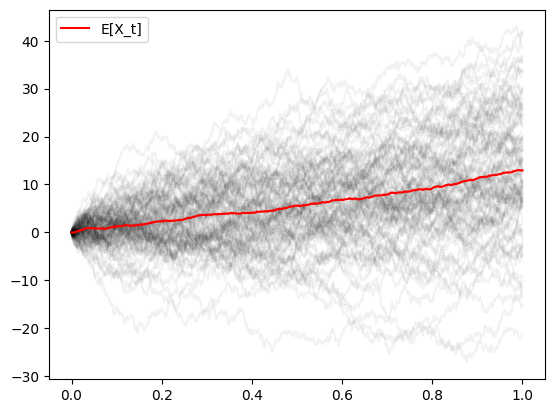

2025-11-08 11:40:23,641 [INFO] ====================================================================================================
2025-11-08 11:40:23,642 [INFO] Time Interval Information
2025-11-08 11:40:23,642 [INFO] ====================================================================================================
2025-11-08 11:40:23,642 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:23,642 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:23,642 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:23,643 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:23,643 [INFO] Number of time points: 1001
2025-11-08 11:40:23,643 [INFO] 

2025-11-08 11:40:23,643 [INFO] ====================================================================================================
2025-11-08 11:40:23,643 [INFO] Team Information
2025-11-08 11:40:23,644 [INFO] ====================================================================================================
2025-11-08 11:40:23,644 




home_poss_factor:  102.696, away_poss_factor:  99.964, avg_poss_factor:  101.330
hbar:  15.523, abar:  16.757
m_h:  1.057 -> adj_m_h:  1.071, m_a:  1.065 -> adj_ma:  1.079
pred_nrtg:  2.325 -> adj_pred_nrtg:  2.356
Differential Game Results


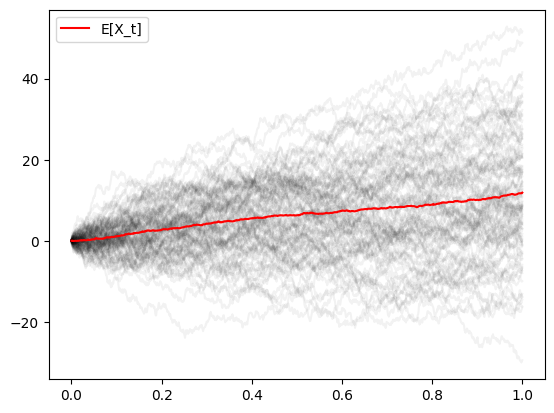

2025-11-08 11:40:25,674 [INFO] Read in data...
2025-11-08 11:40:25,675 [INFO] df_trans: (3690, 104)
2025-11-08 11:40:25,677 [INFO] Convert GAME_DATE to datetime...
2025-11-08 11:40:25,678 [INFO] Split transformed data on 2024-10-23 00:00:00
2025-11-08 11:40:25,679 [INFO] df_trans_train: (2462, 104)
2025-11-08 11:40:25,679 [INFO] Estimating offensive effort...
2025-11-08 11:40:25,681 [INFO] Fitting stage 1 model for OFF EFFORT...
2025-11-08 11:40:25,683 [INFO] Train RMSE:  11.191
2025-11-08 11:40:25,683 [INFO] Creating composite effort...
2025-11-08 11:40:25,684 [INFO] Offensive effort complete.
2025-11-08 11:40:25,685 [INFO] Estimating defensive effort...
2025-11-08 11:40:25,686 [INFO] Fitting stage 1 model for DEF EFFORT...
2025-11-08 11:40:25,689 [INFO] Train RMSE:  10.988
2025-11-08 11:40:25,689 [INFO] Creating composite effort...
2025-11-08 11:40:25,690 [INFO] Defensive effort complete.
2025-11-08 11:40:25,691 [INFO] Estimating net effort...
2025-11-08 11:40:25,694 [INFO] Fitting s




Game Date: 2024-10-23 00:00:00, Number of Games: 10
m_H:  1.05, m_A:  1.06, sigma:  13.58
m_H: 1.054718431352488, m_A: 1.0629778196162394, sigma: 13.576848152666397
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
Optimal Control Parameters
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
home_poss_factor:  101.576, away_poss_factor:  103.132, avg_poss_factor:  102.354
hbar:  17.924, abar:  16.887
m_h:  1.055 -> adj_m_h:  1.080, m_a:  1.063 -> adj_ma:  1.088
pred_nrtg: -8.302 -> adj_pred_nrtg: -8.497
Differential Game Results


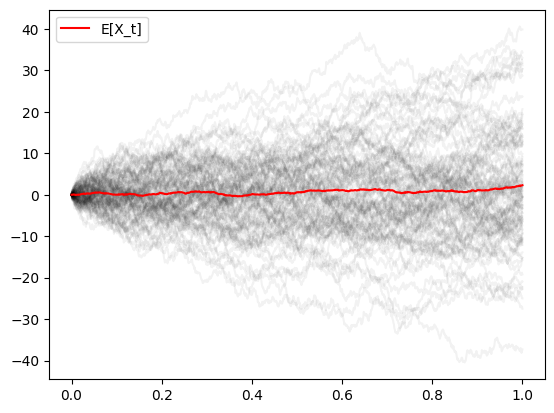

2025-11-08 11:40:27,824 [INFO] ====================================================================================================
2025-11-08 11:40:27,824 [INFO] Time Interval Information
2025-11-08 11:40:27,824 [INFO] ====================================================================================================
2025-11-08 11:40:27,824 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:27,825 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:27,825 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:27,825 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:27,825 [INFO] Number of time points: 1001
2025-11-08 11:40:27,825 [INFO] 

2025-11-08 11:40:27,826 [INFO] ====================================================================================================
2025-11-08 11:40:27,826 [INFO] Team Information
2025-11-08 11:40:27,826 [INFO] ====================================================================================================
2025-11-08 11:40:27,826 




home_poss_factor:  101.008, away_poss_factor:  98.572, avg_poss_factor:  99.790
hbar:  16.299, abar:  15.600
m_h:  1.055 -> adj_m_h:  1.053, m_a:  1.063 -> adj_ma:  1.061
pred_nrtg:  1.402 -> adj_pred_nrtg:  1.399
Differential Game Results


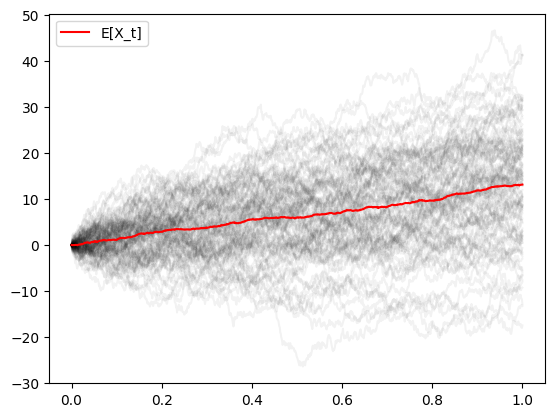

2025-11-08 11:40:29,861 [INFO] ====================================================================================================
2025-11-08 11:40:29,861 [INFO] Time Interval Information
2025-11-08 11:40:29,861 [INFO] ====================================================================================================
2025-11-08 11:40:29,861 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:29,862 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:29,862 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:29,862 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:29,862 [INFO] Number of time points: 1001
2025-11-08 11:40:29,862 [INFO] 

2025-11-08 11:40:29,862 [INFO] ====================================================================================================
2025-11-08 11:40:29,863 [INFO] Team Information
2025-11-08 11:40:29,863 [INFO] ====================================================================================================
2025-11-08 11:40:29,863 




home_poss_factor:  96.276, away_poss_factor:  98.012, avg_poss_factor:  97.144
hbar:  17.224, abar:  17.435
m_h:  1.055 -> adj_m_h:  1.025, m_a:  1.063 -> adj_ma:  1.033
pred_nrtg:  5.111 -> adj_pred_nrtg:  4.965
Differential Game Results


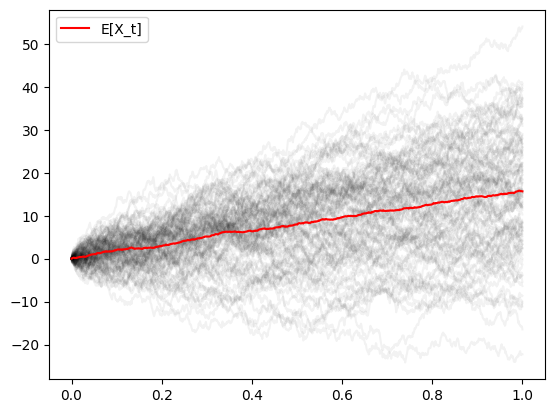

2025-11-08 11:40:31,877 [INFO] ====================================================================================================
2025-11-08 11:40:31,878 [INFO] Time Interval Information
2025-11-08 11:40:31,878 [INFO] ====================================================================================================
2025-11-08 11:40:31,878 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:31,878 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:31,878 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:31,879 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:31,879 [INFO] Number of time points: 1001
2025-11-08 11:40:31,879 [INFO] 

2025-11-08 11:40:31,879 [INFO] ====================================================================================================
2025-11-08 11:40:31,879 [INFO] Team Information
2025-11-08 11:40:31,880 [INFO] ====================================================================================================
2025-11-08 11:40:31,880 




home_poss_factor:  98.756, away_poss_factor:  100.304, avg_poss_factor:  99.530
hbar:  19.941, abar:  15.784
m_h:  1.055 -> adj_m_h:  1.050, m_a:  1.063 -> adj_ma:  1.058
pred_nrtg:  6.276 -> adj_pred_nrtg:  6.247
Differential Game Results


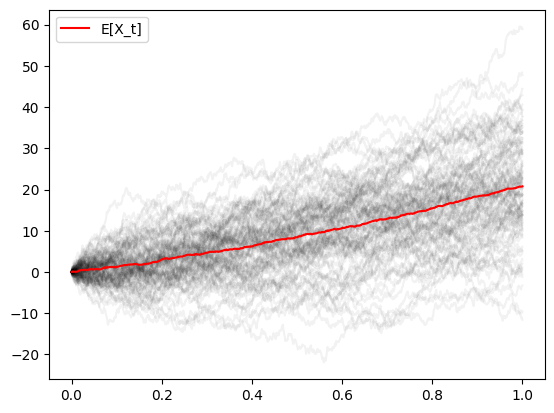

2025-11-08 11:40:33,877 [INFO] ====================================================================================================
2025-11-08 11:40:33,877 [INFO] Time Interval Information
2025-11-08 11:40:33,877 [INFO] ====================================================================================================
2025-11-08 11:40:33,877 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:33,877 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:33,878 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:33,878 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:33,878 [INFO] Number of time points: 1001
2025-11-08 11:40:33,878 [INFO] 

2025-11-08 11:40:33,878 [INFO] ====================================================================================================
2025-11-08 11:40:33,879 [INFO] Team Information
2025-11-08 11:40:33,879 [INFO] ====================================================================================================
2025-11-08 11:40:33,879 




home_poss_factor:  102.976, away_poss_factor:  98.776, avg_poss_factor:  100.876
hbar:  13.859, abar:  17.410
m_h:  1.055 -> adj_m_h:  1.064, m_a:  1.063 -> adj_ma:  1.072
pred_nrtg: -1.973 -> adj_pred_nrtg: -1.990
Differential Game Results


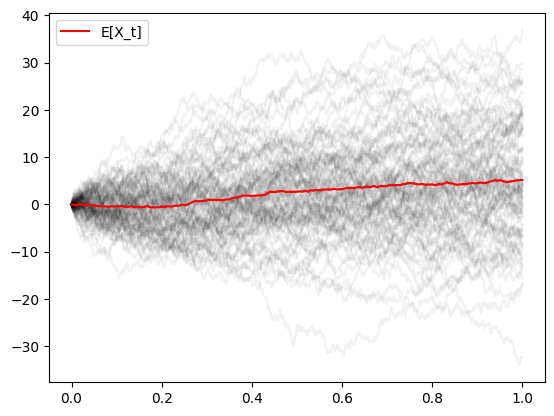

2025-11-08 11:40:36,228 [INFO] ====================================================================================================
2025-11-08 11:40:36,228 [INFO] Time Interval Information
2025-11-08 11:40:36,228 [INFO] ====================================================================================================
2025-11-08 11:40:36,228 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:36,229 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:36,229 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:36,229 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:36,229 [INFO] Number of time points: 1001
2025-11-08 11:40:36,229 [INFO] 

2025-11-08 11:40:36,230 [INFO] ====================================================================================================
2025-11-08 11:40:36,230 [INFO] Team Information
2025-11-08 11:40:36,230 [INFO] ====================================================================================================
2025-11-08 11:40:36,230 




home_poss_factor:  100.976, away_poss_factor:  97.760, avg_poss_factor:  99.368
hbar:  17.813, abar:  16.646
m_h:  1.055 -> adj_m_h:  1.048, m_a:  1.063 -> adj_ma:  1.056
pred_nrtg:  2.662 -> adj_pred_nrtg:  2.645
Differential Game Results


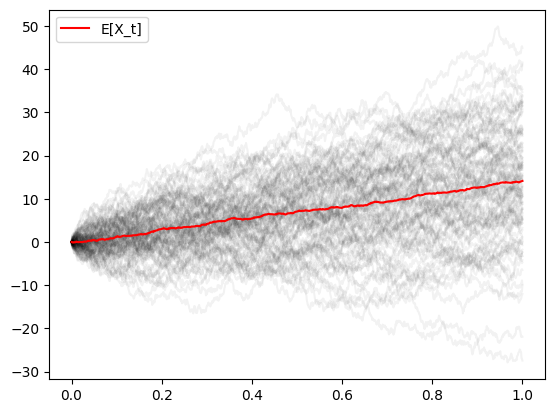

2025-11-08 11:40:38,229 [INFO] ====================================================================================================
2025-11-08 11:40:38,230 [INFO] Time Interval Information
2025-11-08 11:40:38,230 [INFO] ====================================================================================================
2025-11-08 11:40:38,230 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:38,230 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:38,231 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:38,231 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:38,231 [INFO] Number of time points: 1001
2025-11-08 11:40:38,231 [INFO] 

2025-11-08 11:40:38,231 [INFO] ====================================================================================================
2025-11-08 11:40:38,232 [INFO] Team Information
2025-11-08 11:40:38,232 [INFO] ====================================================================================================
2025-11-08 11:40:38,232 




home_poss_factor:  97.996, away_poss_factor:  101.124, avg_poss_factor:  99.560
hbar:  16.818, abar:  17.078
m_h:  1.055 -> adj_m_h:  1.050, m_a:  1.063 -> adj_ma:  1.058
pred_nrtg:  1.219 -> adj_pred_nrtg:  1.214
Differential Game Results


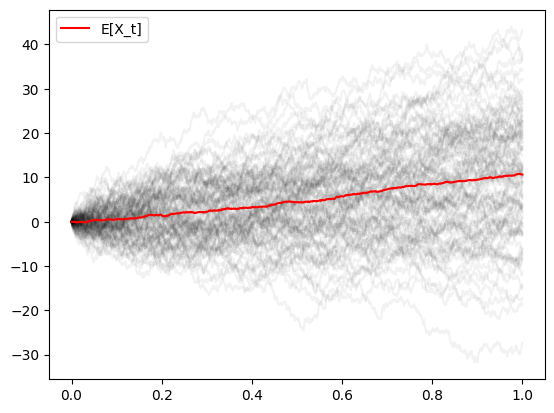

2025-11-08 11:40:40,263 [INFO] ====================================================================================================
2025-11-08 11:40:40,264 [INFO] Time Interval Information
2025-11-08 11:40:40,264 [INFO] ====================================================================================================
2025-11-08 11:40:40,264 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:40,264 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:40,265 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:40,265 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:40,265 [INFO] Number of time points: 1001
2025-11-08 11:40:40,265 [INFO] 

2025-11-08 11:40:40,265 [INFO] ====================================================================================================
2025-11-08 11:40:40,266 [INFO] Team Information
2025-11-08 11:40:40,266 [INFO] ====================================================================================================
2025-11-08 11:40:40,266 




home_poss_factor:  99.728, away_poss_factor:  101.108, avg_poss_factor:  100.418
hbar:  13.377, abar:  17.409
m_h:  1.055 -> adj_m_h:  1.059, m_a:  1.063 -> adj_ma:  1.067
pred_nrtg:  3.642 -> adj_pred_nrtg:  3.657
Differential Game Results


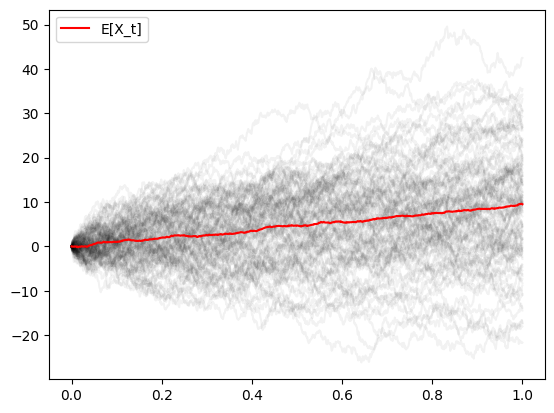

2025-11-08 11:40:42,347 [INFO] ====================================================================================================
2025-11-08 11:40:42,347 [INFO] Time Interval Information
2025-11-08 11:40:42,348 [INFO] ====================================================================================================
2025-11-08 11:40:42,348 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:42,348 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:42,348 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:42,349 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:42,349 [INFO] Number of time points: 1001
2025-11-08 11:40:42,349 [INFO] 

2025-11-08 11:40:42,349 [INFO] ====================================================================================================
2025-11-08 11:40:42,349 [INFO] Team Information
2025-11-08 11:40:42,350 [INFO] ====================================================================================================
2025-11-08 11:40:42,350 




home_poss_factor:  99.216, away_poss_factor:  97.640, avg_poss_factor:  98.428
hbar:  14.839, abar:  16.062
m_h:  1.055 -> adj_m_h:  1.038, m_a:  1.063 -> adj_ma:  1.046
pred_nrtg:  1.644 -> adj_pred_nrtg:  1.619
Differential Game Results


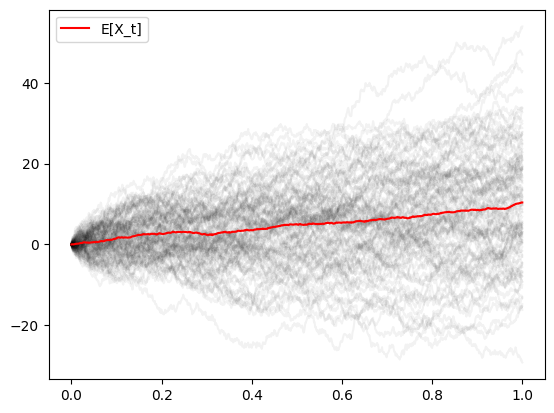

2025-11-08 11:40:44,328 [INFO] ====================================================================================================
2025-11-08 11:40:44,329 [INFO] Time Interval Information
2025-11-08 11:40:44,329 [INFO] ====================================================================================================
2025-11-08 11:40:44,329 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:44,329 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:44,329 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:44,330 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:44,330 [INFO] Number of time points: 1001
2025-11-08 11:40:44,330 [INFO] 

2025-11-08 11:40:44,330 [INFO] ====================================================================================================
2025-11-08 11:40:44,330 [INFO] Team Information
2025-11-08 11:40:44,331 [INFO] ====================================================================================================
2025-11-08 11:40:44,331 




home_poss_factor:  98.688, away_poss_factor:  98.380, avg_poss_factor:  98.534
hbar:  14.074, abar:  19.102
m_h:  1.055 -> adj_m_h:  1.039, m_a:  1.063 -> adj_ma:  1.047
pred_nrtg: -8.904 -> adj_pred_nrtg: -8.773
Differential Game Results


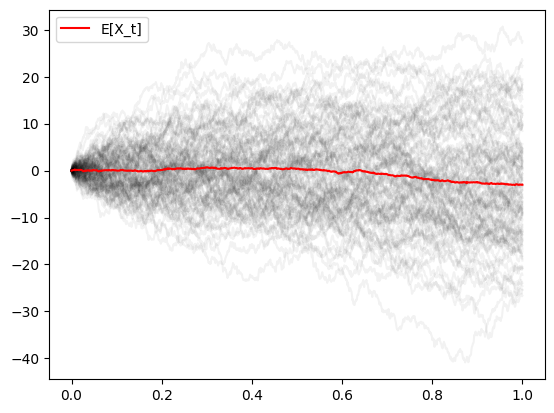

2025-11-08 11:40:46,330 [INFO] Read in data...
2025-11-08 11:40:46,330 [INFO] df_trans: (3690, 104)
2025-11-08 11:40:46,333 [INFO] Convert GAME_DATE to datetime...
2025-11-08 11:40:46,335 [INFO] Split transformed data on 2024-10-24 00:00:00
2025-11-08 11:40:46,336 [INFO] df_trans_train: (2472, 104)
2025-11-08 11:40:46,336 [INFO] Estimating offensive effort...
2025-11-08 11:40:46,338 [INFO] Fitting stage 1 model for OFF EFFORT...
2025-11-08 11:40:46,342 [INFO] Train RMSE:  11.188
2025-11-08 11:40:46,342 [INFO] Creating composite effort...
2025-11-08 11:40:46,343 [INFO] Offensive effort complete.
2025-11-08 11:40:46,344 [INFO] Estimating defensive effort...
2025-11-08 11:40:46,346 [INFO] Fitting stage 1 model for DEF EFFORT...
2025-11-08 11:40:46,348 [INFO] Train RMSE:  10.981
2025-11-08 11:40:46,349 [INFO] Creating composite effort...
2025-11-08 11:40:46,350 [INFO] Defensive effort complete.
2025-11-08 11:40:46,350 [INFO] Estimating net effort...
2025-11-08 11:40:46,353 [INFO] Fitting s




Game Date: 2024-10-24 00:00:00, Number of Games: 4
m_H:  1.05, m_A:  1.06, sigma:  13.58
m_H: 1.0518847510798321, m_A: 1.059477406632754, sigma: 13.580690883941054
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
Optimal Control Parameters
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
home_poss_factor:  99.044, away_poss_factor:  99.616, avg_poss_factor:  99.330
hbar:  18.162, abar:  16.374
m_h:  1.052 -> adj_m_h:  1.045, m_a:  1.059 -> adj_ma:  1.052
pred_nrtg:  3.143 -> adj_pred_nrtg:  3.122
Differential Game Results


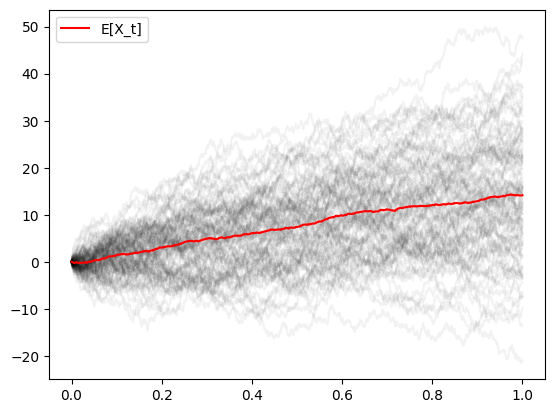

2025-11-08 11:40:48,459 [INFO] ====================================================================================================
2025-11-08 11:40:48,460 [INFO] Time Interval Information
2025-11-08 11:40:48,460 [INFO] ====================================================================================================
2025-11-08 11:40:48,460 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:48,460 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:48,460 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:48,461 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:48,461 [INFO] Number of time points: 1001
2025-11-08 11:40:48,461 [INFO] 

2025-11-08 11:40:48,461 [INFO] ====================================================================================================
2025-11-08 11:40:48,461 [INFO] Team Information
2025-11-08 11:40:48,462 [INFO] ====================================================================================================
2025-11-08 11:40:48,462 




home_poss_factor:  98.776, away_poss_factor:  100.920, avg_poss_factor:  99.848
hbar:  16.075, abar:  18.810
m_h:  1.052 -> adj_m_h:  1.050, m_a:  1.059 -> adj_ma:  1.058
pred_nrtg:  2.500 -> adj_pred_nrtg:  2.497
Differential Game Results


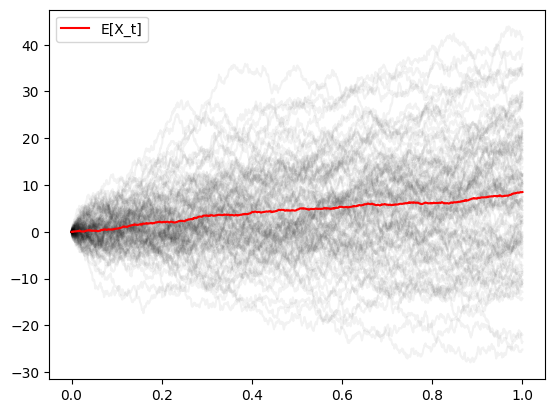

2025-11-08 11:40:50,469 [INFO] ====================================================================================================
2025-11-08 11:40:50,470 [INFO] Time Interval Information
2025-11-08 11:40:50,470 [INFO] ====================================================================================================
2025-11-08 11:40:50,470 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:50,470 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:50,470 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:50,471 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:50,471 [INFO] Number of time points: 1001
2025-11-08 11:40:50,471 [INFO] 

2025-11-08 11:40:50,471 [INFO] ====================================================================================================
2025-11-08 11:40:50,471 [INFO] Team Information
2025-11-08 11:40:50,472 [INFO] ====================================================================================================
2025-11-08 11:40:50,472 




home_poss_factor:  104.068, away_poss_factor:  97.148, avg_poss_factor:  100.608
hbar:  16.445, abar:  16.245
m_h:  1.052 -> adj_m_h:  1.058, m_a:  1.059 -> adj_ma:  1.066
pred_nrtg: -4.003 -> adj_pred_nrtg: -4.027
Differential Game Results


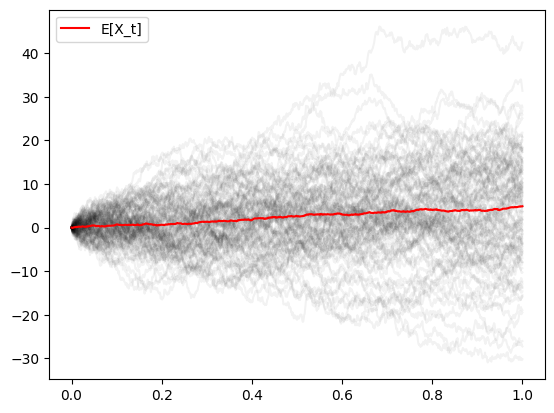

2025-11-08 11:40:52,486 [INFO] ====================================================================================================
2025-11-08 11:40:52,487 [INFO] Time Interval Information
2025-11-08 11:40:52,487 [INFO] ====================================================================================================
2025-11-08 11:40:52,487 [INFO] Time Scale: Proportion of Game Played
2025-11-08 11:40:52,487 [INFO] Total Time Interval: [0,1]
2025-11-08 11:40:52,487 [INFO] Sub-interval length: Δt = 0.001
2025-11-08 11:40:52,488 [INFO] Number of sub-intervals: 1000
2025-11-08 11:40:52,488 [INFO] Number of time points: 1001
2025-11-08 11:40:52,488 [INFO] 

2025-11-08 11:40:52,488 [INFO] ====================================================================================================
2025-11-08 11:40:52,488 [INFO] Team Information
2025-11-08 11:40:52,489 [INFO] ====================================================================================================
2025-11-08 11:40:52,489 




home_poss_factor:  102.120, away_poss_factor:  104.388, avg_poss_factor:  103.254
hbar:  16.550, abar:  16.995
m_h:  1.052 -> adj_m_h:  1.086, m_a:  1.059 -> adj_ma:  1.094
pred_nrtg:  3.376 -> adj_pred_nrtg:  3.486
Differential Game Results


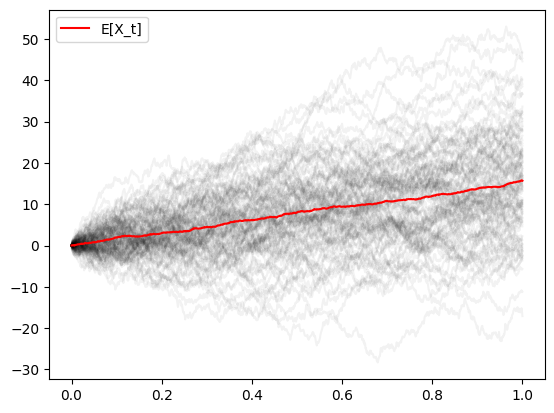

In [8]:
# Stage 1 Parameters
off_effort_list = []
def_effort_list = []

# Stage 2 Parameters
home_adv_list = []
avg_efg_pct_diff_list = []
avg_fta_rate_diff_list = []
avg_tm_tov_pct_diff_list = []
avg_oreb_pct_diff_list = []

# Stage 3 Parameters
home_net_effort_list = []
away_net_effort_list = []
m_H_list = []
m_A_list = []
sigma_list = []

for game_date in dates[:3]:
    df_trans = df_transformed.copy()
    #print("="*100)
    num_games = len(df_trans[df_trans['GAME_DATE_dt']==game_date])
    print(f"Game Date: {game_date}, Number of Games: {num_games}")
    # print("="*100)
    # print("Transformed Data Sample:")
    df_trans_prior = df_trans[df_trans['GAME_DATE_dt']<game_date].copy()
    #print(df_trans_prior[df_trans_prior['GAME_DATE_dt']==(game_date-pd.Timedelta(days=1))][['GAME_DATE','HOME_TEAM_NAME','AWAY_TEAM_NAME','EST_HOME_POSS','EST_AWAY_POSS']])
    h_poss = df_trans_prior.groupby('HOME_TEAM_ABBREVIATION').tail(WINDOW).groupby('HOME_TEAM_ABBREVIATION')['EST_HOME_POSS'].mean()
    a_poss = df_trans_prior.groupby('AWAY_TEAM_ABBREVIATION').tail(WINDOW).groupby('AWAY_TEAM_ABBREVIATION')['EST_AWAY_POSS'].mean()
    df_poss = pd.DataFrame({'Home_Avg_Poss':h_poss, 'Away_Avg_Poss':a_poss})
    # print("%"*50)
    # print(df_poss[df_poss.index=='BKN'])
    # print("%"*50)
    #print(df_trans[df_trans['GAME_DATE_dt']<game_date][['EST_HOME_POSS','EST_AWAY_POSS']].mean())
    # Estimate stage 1 effort with all latest data
    df_stage1, model_stage1 = run_stage1(
        df_transformed=df_trans,
        output_dir=stage1_output_dir,
        current_date=game_date, 
        save_figs=False, 
        print_output=False, 
        create_plots=False, 
        save_data=False
    )
    df_stage1['GAME_DATE'] = pd.to_datetime(df_stage1['GAME_DATE'])
    # print("Stage 1 effort estimation complete.")
    # print("Stage1 Model Summary:")
    # #print(model_stage1.summary())
    # print("Model Coefficient Estimates:")
    # print(model_stage1.params)
    off_effort_list.append(model_stage1.params.iloc[1])
    def_effort_list.append(model_stage1.params.iloc[2])
    

    # Predict current date's net ratings
    # y_train_pred in df_train_stage2: train data predictions are for all data PRIOR to current date (used in stage 3 model to estimate m_h, m_a, sigma)
    # y_test_pred in df_test_stage2: test data predictions are for all current date's games (used in actual prediction in the drift term of current game's opimtal control problem)
    df_train_stage2, df_test_stage2, model_stage2 = run_stage2(
        df_transformed=df_trans,
        df_stage1_output=df_stage1,
        output_dir=stage2_output_dir,
        current_date=game_date, 
        window=WINDOW, 
        save_figs=False, 
        print_output=False, 
        create_plots=False, 
        save_data=False
    )
    # print("Stage 2 net rating estimation complete.")
    # print("Stage2 Model Summary:")
    # #print(model_stage2.summary())
    # print("Model Coefficient Estimates:")
    # print(model_stage2.params)
    home_adv_list.append(model_stage2.params.iloc[0])
    avg_efg_pct_diff_list.append(model_stage2.params.iloc[1])
    avg_fta_rate_diff_list.append(model_stage2.params.iloc[2])
    avg_tm_tov_pct_diff_list.append(model_stage2.params.iloc[3])
    avg_oreb_pct_diff_list.append(model_stage2.params.iloc[4])


    # Take y_pred_train and use as a predictor of current game net rating for all games prior to today
    # Output: m_H_est, m_A_est, sigma_est
    m_H, m_A, sigma_est, model_stage3 = run_stage3(
        df_transformed=df_trans, 
        df_stage1_output=df_stage1,
        df_train_stage2_output=df_train_stage2,
        current_date=game_date,
        window=WINDOW,
        output_dir=stage3_output_dir
    )

    # print("Stage 3 drift parameter estimation complete.")
    # print("Stage3 Model Summary:")
    # #print(model_stage3.summary())
    # print("Drift Parameter Estimates:")
    print(f"m_H: {m_H}, m_A: {m_A}, sigma: {sigma_est}")
    home_net_effort_list.append(model_stage3.params.iloc[0])
    away_net_effort_list.append(model_stage3.params.iloc[1])
    m_H_list.append(m_H)
    m_A_list.append(m_A)
    sigma_list.append(sigma_est)


    # Now, once we have all pices to the puzzle (y_pred_test, m_h, m_a, sigma, hbar), we can solve the optimal control problem for each game of todays games
    print("$"*150)
    print("Optimal Control Parameters")
    print("$"*150)
    for index, row in df_test_stage2.iterrows():
        hbar = row[f'HOME_AVG{WINDOW}_NET_COMPOSITE_EFFORT']
        abar = row[f'AWAY_AVG{WINDOW}_NET_COMPOSITE_EFFORT']
        m_h = m_H
        m_a = m_A
        sigma = sigma_est
        pred_nrtg = row['y_pred_test']
        home_team = row['HOME_TEAM']
        away_team = row['AWAY_TEAM']
        home_poss_factor = df_poss.loc[df_poss.index==home_team,'Home_Avg_Poss'].values[0] # necessary (possible?) with net calculation
        away_poss_factor = df_poss.loc[df_poss.index==away_team,'Away_Avg_Poss'].values[0] # necessary (possible?) with net calculation
        avg_poss_factor = (home_poss_factor + away_poss_factor)/2
        m_h_adj = m_h*avg_poss_factor/100
        m_a_adj = m_a*avg_poss_factor/100
        sigma_adj = sigma*avg_poss_factor/100
        pred_nrtg_adj = pred_nrtg*avg_poss_factor/100
        print(f"home_poss_factor: {home_poss_factor: .3f}, away_poss_factor: {away_poss_factor: .3f}, avg_poss_factor: {avg_poss_factor: .3f}")
        print(f"hbar: {hbar: .3f}, abar: {abar: .3f}")
        print(f"m_h: {m_h: .3f} -> adj_m_h: {m_h*avg_poss_factor/100: .3f}, m_a: {m_a: .3f} -> adj_ma: {m_a*avg_poss_factor/100: .3f}")
        print(f"pred_nrtg: {pred_nrtg: .3f} -> adj_pred_nrtg: {pred_nrtg*avg_poss_factor/100: .3f}")
        
        
        sgs = SingleGameSim(
            hbar = hbar,
            abar = abar,
            pred_nrtg = pred_nrtg_adj,
            dt = None,
            n_points = config.simulation['n_points'],
            n_sim = config.simulation['n_sim'],
            T = 1,  
            m_H = m_h_adj, # Need to estimate with additional linear model
            m_A = m_a_adj, # Need to estimate with additional linear model
            alpha_H = .1, # Need to choose based on risk tolerance
            alpha_A = .1, # Need to choose based on risk tolerance
            sigma = sigma_adj 
        )
        print("="*100)
        print("Differential Game Results")
        print("="*100)
        sgs.results_summary(interval_prob=.9)
        sgs.euler_maruyama()
        sgs.plot_paths()
        plt.show()
        
        print("\n\n")
    


NameError: name 'df_poss' is not defined

In [29]:
a_cols = ['GAME_DATE','HOME_TEAM_ABBREVIATION','AWAY_TEAM_ABBREVIATION','EST_HOME_POSS','EST_AWAY_POSS']
a = df_trans_prior[a_cols]
a.groupby('HOME_TEAM_ABBREVIATION').tail(10).groupby('HOME_TEAM_ABBREVIATION')['EST_HOME_POSS'].mean().reset_index()

,HOME_TEAM_ABBREVIATION,EST_HOME_POSS
0,ATL,102.752
1,BKN,97.284
2,BOS,97.584
3,CHA,97.060
4,CHI,97.376
5,CLE,97.976
6,DAL,102.520
7,DEN,99.188
8,DET,100.808
9,GSW,100.984


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df_drift_params = pd.DataFrame({
    'GAME_DATE': dates.values,
    'off_effort': off_effort_list,
    'def_effort': def_effort_list,
    'home_adv': home_adv_list,
    'avg_efg_pct_diff': avg_efg_pct_diff_list,
    'avg_fta_rate_diff': avg_fta_rate_diff_list,
    'avg_tm_tov_pct_diff': avg_tm_tov_pct_diff_list,
    'avg_oreb_pct_diff': avg_oreb_pct_diff_list,
    'home_net_effort': home_net_effort_list,
    'away_net_effort': away_net_effort_list,
    'm_H': m_H_list,
    'm_A': m_A_list,
    'sigma': sigma_list
})
df_drift_params['GAME_DATE'] = pd.to_datetime(df_drift_params['GAME_DATE'])

# Off/Def Effort
plt.figure(figsize=(12,6))
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='off_effort', marker='o', label='Offensive Effort')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='def_effort', marker='o', label='Defensive Effort')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='home_adv', marker='o', label='Home Advantage')
plt.title('Effort Effects Over Time')
plt.xlabel('Game Date')
plt.ylabel('Effort Parameter Value')
plt.legend()
plt.grid()
plt.show()

# Avg Four Factors Diff
plt.figure(figsize=(12,6))
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='avg_efg_pct_diff', marker='o', label='Avg EFG% Diff')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='avg_fta_rate_diff', marker='o', label='Avg FTA Rate Diff')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='avg_tm_tov_pct_diff', marker='o', label='Avg TOV% Diff')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='avg_oreb_pct_diff', marker='o', label='Avg OREB% Diff')
plt.title('Four Factors Effects Over Time')
plt.xlabel('Game Date')
plt.ylabel('Four Factor Parameter Value')
plt.legend()
plt.grid()
plt.show()

# Net Effort
plt.figure(figsize=(12,6))
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='home_net_effort', marker='o', label='Home Effort')
sns.lineplot(data=df_drift_params, x='GAME_DATE',y='away_net_effort', marker='o', label='Away Effort')
plt.title('Home/Away Net Effort Over Time')
plt.xlabel('Game Date')
plt.ylabel('Net Effort Parameter Value')
plt.legend()
plt.grid()
plt.show()
# m_H and m_A
plt.figure(figsize=(12,6))
sns.lineplot(data=df_drift_params, x='GAME_DATE', y='m_H', marker='o', label='m_H')
sns.lineplot(data=df_drift_params, x='GAME_DATE', y='m_A', marker='o', label='m_A')
plt.title('Drift Parameters Over Time')
plt.xlabel('Game Date')
plt.ylabel('Drift Parameter Value')
plt.legend()
plt.grid()
plt.show()
# Sigma
plt.figure(figsize=(12,6))
sns.lineplot(data=df_drift_params, x='GAME_DATE', y='sigma', marker='o', color='orange')
plt.title('Sigma Over Time')
plt.xlabel('Game Date')
plt.ylabel('Sigma Value')
plt.grid()
plt.show()
print("Drift Parameters DataFrame:")
print(df_drift_params)